# Проект по детектированию медицинских масок 

Проект направлен на решение задачи обнаружения медицинских масок с использованием переноса результатов обучения 
(transfer learning)  сетей Faster R-CNN и YOLOv8.
Использован датасет https://www.kaggle.com/datasets/andrewmvd/face-mask-detection, который содержит 853 изображений и аннотаций к ним, 3 класса объектов (с маской, без маски, некорректно одетая маска).
Перед использованием модуля необходимо скачать архив датасета с kaggle и распаковать его в директорию с модулем.
В проекте результаты получены на 'cpu', поэтому длительность обучения ограничена 5 эпохами.


# Импорт библиотек

In [1]:
# based on https://www.kaggle.com/konstanter/fasterrcnn-pytorch-maskdetection

import numpy as np 
import pandas as pd 
import torchvision
from torchvision import transforms, datasets, models
from torchvision.ops import box_iou
import torch
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import shutil
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
import cv2
import os
import glob
import random
import xml.etree.ElementTree as et
import time
from ultralytics import YOLO
from tqdm import tqdm
from pathlib import Path

%matplotlib inline

# Загрузка данных в DataLoader

In [2]:
# путь к файлам
images_dir = './images/'
annotations_dir = './annotations/'


class FaceMaskDataset(torch.utils.data.Dataset):

    def __init__(self, images_dir, annotation_dir,width, height, transforms=None):
        self.transforms = transforms
        self.images_dir = images_dir
        self.annotation_dir = annotation_dir
        self.height = height
        self.width = width
        
        # сортировка изображений
        self.imgs = [image for image in sorted(os.listdir(images_dir))]
        self.annotate = [image for image in sorted(os.listdir(annotation_dir))]
        
        # на 0й позиции находится фон
        self.classes = [_, 'without_mask','with_mask','mask_weared_incorrect']

    def __getitem__(self, idx):

        img_name = self.imgs[idx]
        image_path = os.path.join(self.images_dir, img_name)

        # изменение цвета и размера изображения    
        img = cv2.imread(image_path)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img_res = cv2.resize(img_rgb, (self.width, self.height), cv2.INTER_AREA)
        #print('img = ', img.shape, 'img_rgb=', len(img_rgb), 'img_res=', len(img_res))
        # нормализация изображения
        img_res /= 255.0
        
        # аннотация
        annot_filename = self.annotate[idx]
        annot_file_path = os.path.join(self.annotation_dir, annot_filename)
        
        boxes = []
        labels = []
        tree = et.parse(annot_file_path)
        root = tree.getroot()
        
        # высота и ширина изобрадения
        wt = img.shape[1]
        ht = img.shape[0]
        
        # ограничивающие рамки
        for member in root.findall('object'):
            labels.append(self.classes.index(member.find('name').text))
            
            # bounding box
            xmin = int(member.find('bndbox').find('xmin').text)
            xmax = int(member.find('bndbox').find('xmax').text)
            if xmax > wt:
                xmax = wt
            
            ymin = int(member.find('bndbox').find('ymin').text)
            ymax = int(member.find('bndbox').find('ymax').text)
            
            
            xmin_corr = (xmin/wt)*self.width
            xmax_corr = (xmax/wt)*self.width
            ymin_corr = (ymin/ht)*self.height
            ymax_corr = (ymax/ht)*self.height
            
            boxes.append([xmin_corr, ymin_corr, xmax_corr, ymax_corr])
        #print('boxes=', boxes, 'shape=', type(boxes))
        # перевод boxes в формат torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        #print('boxes=', boxes, 'shape=', boxes.shape)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)
        
        labels = torch.as_tensor(labels, dtype=torch.int64)


        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["area"] = area
        target["iscrowd"] = iscrowd

        image_id = torch.tensor([idx])
        target["image_id"] = image_id


        if self.transforms:
            
            sample = self.transforms(image = img_res,
                                     bboxes = target['boxes'],
                                     labels = labels)
            
            img_res = sample['image']
            target['boxes'] = torch.Tensor(sample['bboxes'])
            
            
            
        return img_res, target

    def __len__(self):
        return len(self.imgs)


# проверка датасета
dataset = FaceMaskDataset(images_dir, annotations_dir, 224, 224)
print('length of dataset = ', len(dataset), '\n')

img, target = dataset[78]
print('Image shape = ', img.shape, '\n','Target - ', target)

length of dataset =  853 

Image shape =  (224, 224, 3) 
 Target -  {'boxes': tensor([[113.1163, 146.7200, 163.7209, 205.5200]]), 'labels': tensor([2]), 'area': tensor([2975.5537]), 'iscrowd': tensor([0]), 'image_id': tensor([78])}


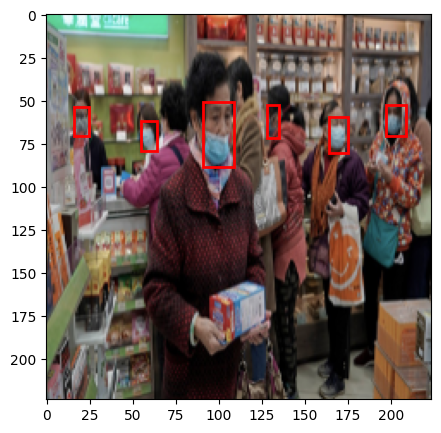

In [3]:
# Вспомогательная функция для визуализации bbox

def plot_img_bbox(img, target):
    fig, a = plt.subplots(1,1)
    fig.set_size_inches(5,5)
    a.imshow(img)
    
    for box in (target['boxes']):
        x, y, width, height  = box[0], box[1], box[2]-box[0], box[3]-box[1]
        rect = patches.Rectangle((x, y),
                                 width, height,
                                 linewidth = 2,
                                 edgecolor = 'r',
                                 facecolor = 'none')

        # Отрисуем bbox поверх картинки
        a.add_patch(rect)
    plt.show()
    
img, target = dataset[35]
plot_img_bbox(img, target)

In [4]:
def get_transform(train):
    
    if train:
        return A.Compose([
                            #A.HorizontalFlip(0.5),
                            #A.RandomBrightnessContrast(p=0.2),
                            #A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
                            ToTensorV2(p=1.0) 
                        ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})
    else:
        return A.Compose([
                            ToTensorV2(p=1.0)
                        ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [6]:
dataset = FaceMaskDataset(images_dir, annotations_dir, 480, 480, transforms= get_transform(train=True))
dataset_test = FaceMaskDataset(images_dir, annotations_dir, 480, 480, transforms= get_transform(train=False))

# разделим данные на train и test
torch.manual_seed(1)
indices = torch.randperm(len(dataset)).tolist()

test_split = 0.2
tsize = int(len(dataset)*test_split)
dataset = torch.utils.data.Subset(dataset, indices[:-tsize])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-tsize:])
print('dataset=', len(dataset), 'dataset_test=', len(dataset_test))

data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=10, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=10, shuffle=False, num_workers=0,
    collate_fn=collate_fn)

dataset= 683 dataset_test= 170


# Обучение модели

In [7]:
def get_model_instance_segmentation(num_classes):
    # создаем предобученную модель с архитектурой Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True) # (weights='DEFAULT')
   
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # заменяем финальный  классификатор на новый для num_classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [8]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

num_classes = 4

model = get_model_instance_segmentation(num_classes)

num_epochs = 5

model.to(device)


params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,
                                momentum=0.9, weight_decay=0.0005)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=3,
                                               gamma=0.1)
len_dataloader = len(data_loader)

for epoch in range(num_epochs):
    model.train()
    i = 0    
    epoch_loss = 0
    start_time = time.time()  # старт замера времени
    for imgs, annotations in data_loader:
        i += 1
        imgs = list(img.to(device) for img in imgs)
        annotations = [{k: v.to(device) for k, v in t.items()} for t in annotations]
        loss_dict = model(imgs, annotations)
        losses = sum(loss for loss in loss_dict.values())        

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()         
        epoch_loss += losses.item()
    epoch_time_sec = time.time() - start_time
    epoch_time_min = epoch_time_sec / 60  # перевод в минуты
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Loss: {epoch_loss:.4f} | "
          f"Time: {epoch_time_min:.2f} min")
    lr_scheduler.step()
    #print('Epoch_loss = ',epoch_loss)


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5] | Loss: 35.6558 | Time: 143.71 min
Epoch [2/5] | Loss: 22.3438 | Time: 139.35 min
Epoch [3/5] | Loss: 18.3250 | Time: 138.76 min
Epoch [4/5] | Loss: 15.9634 | Time: 141.23 min
Epoch [5/5] | Loss: 15.2961 | Time: 140.82 min


In [9]:
# после обучения сохраняем параметры обученной модели в файле
torch.save(model.state_dict(), "fasterrcnn_4cls_cpu.pth")

# быстрая проверка
state = torch.load("fasterrcnn_4cls_cpu.pth")
print(state["roi_heads.box_predictor.cls_score.weight"].shape)



torch.Size([4, 1024])


In [7]:
'''
# ВСПОМОГАТЕЛЬНАЯ - ДЛЯ ВОССТАНОВЛЕНИЯ  ОБУЧЕННОЙ МОДЕЛИ,  ИСПОЛЬЗУЯ СОХРАНЕННЫЕ ПАРАМЕТРЫ В ФАЙЛЕ
num_classes = 4
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.load_state_dict(torch.load("fasterrcnn_4cls_cpu.pth", map_location="cpu"))
'''

C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [10]:
# вспомогательная функция принимает исходный прогноз и порог iou

def apply_nms(orig_prediction, iou_thresh=0.3):
    
    keep = torchvision.ops.nms(orig_prediction['boxes'], orig_prediction['scores'], iou_thresh)
    
    final_prediction = orig_prediction
    final_prediction['boxes'] = final_prediction['boxes'][keep]
    final_prediction['scores'] = final_prediction['scores'][keep]
    final_prediction['labels'] = final_prediction['labels'][keep]
    
    return final_prediction

def torch_to_pil(img):
    return transforms.ToPILImage()(img).convert('RGB')

In [11]:
img, target = dataset_test[4]
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.eval()
with torch.no_grad():
    prediction = model([img.to(device)])[0]
    
print('predicted #boxes: ', len(prediction['labels']))
print('real #boxes: ', len(target['labels']))

predicted #boxes:  2
real #boxes:  1


EXPECTED OUTPUT


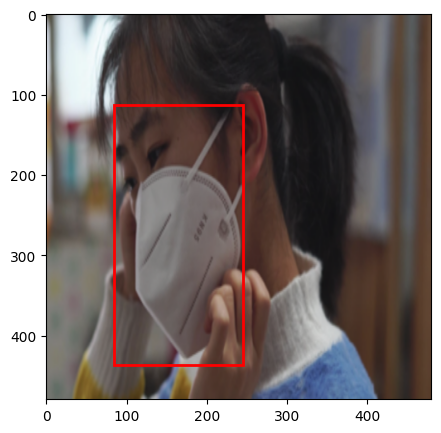

In [12]:
print('EXPECTED OUTPUT')
plot_img_bbox(torch_to_pil(img), target)

MODEL OUTPUT
tensor([[ 96.1386,  93.5994, 251.8320, 427.9494],
        [ 87.5012,  48.6634, 365.5213, 447.7844]])
<class 'torch.Tensor'>


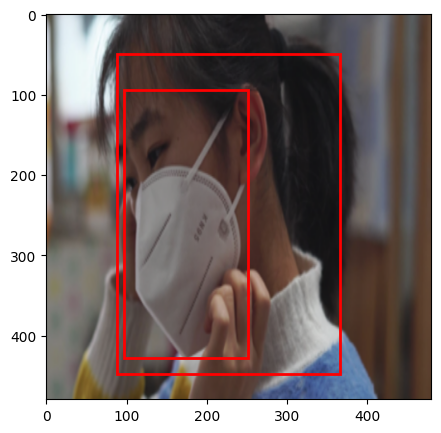

In [11]:
print('MODEL OUTPUT')
plot_img_bbox(torch_to_pil(img), prediction)

NMS APPLIED MODEL OUTPUT
tensor([[ 96.1386,  93.5994, 251.8320, 427.9494]])
<class 'torch.Tensor'>


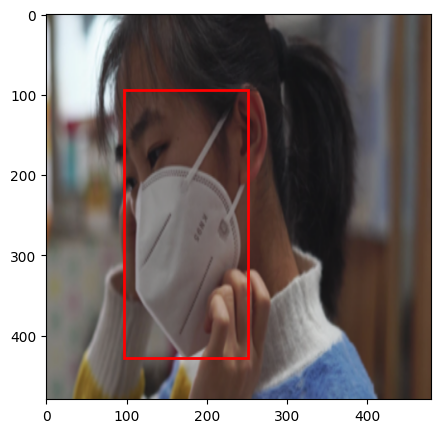

In [12]:
nms_prediction = apply_nms(prediction, iou_thresh=0.2)
print('NMS APPLIED MODEL OUTPUT')
plot_img_bbox(torch_to_pil(img), nms_prediction)

# Отрисовка изображений

In [13]:
def plot_image(img_tensor, annotation,predict=True):
    
    fig,ax = plt.subplots(1)
    fig.set_size_inches(18.5, 10.5)
    img = img_tensor.cpu().data
    mask_dic = {1:'without_mask', 2:'with_mask', 3:'mask_weared_incorrect'}

    ax.imshow(img.permute(1, 2, 0))
    
    for i,box in enumerate(annotation["boxes"]):
        xmin, ymin, xmax, ymax = box

        rect = patches.Rectangle((xmin,ymin),(xmax-xmin),(ymax-ymin),linewidth=1,edgecolor='r',facecolor='none')

        ax.add_patch(rect)
        label = mask_dic[int(annotation['labels'][i].data)]
        if predict:
            score = int((annotation['scores'][i].data) * 100)
            ax.text(xmin, ymin, f"{label} : {score}%", horizontalalignment='center', verticalalignment='center',fontsize=20,color='b')
        else:
            score=''
            ax.text(xmin, ymin, f"{label}", horizontalalignment='center', verticalalignment='center',fontsize=20,color='b')
    plt.show()

In [14]:
for imgs, annotations in data_loader:
        imgs = list(img.to(device) for img in imgs)
        annotations = [{k: v.to(device) for k, v in t.items()} for t in annotations]
        break

In [15]:
model.eval()
#preds = model(imgs)
with torch.no_grad():
    preds = model(imgs)

Prediction


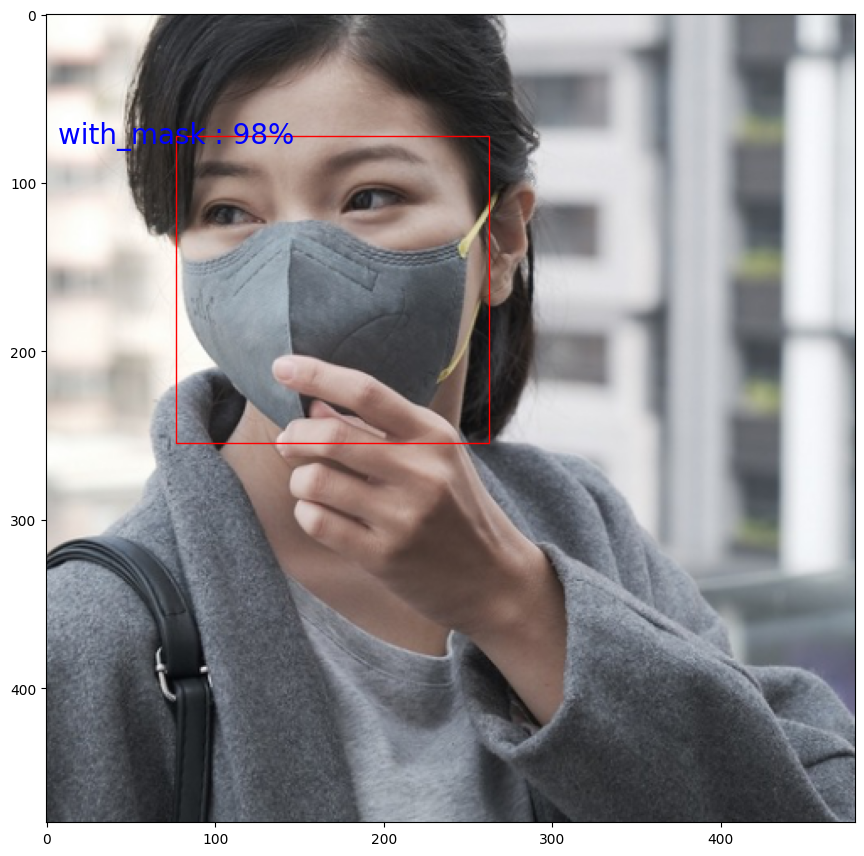

Target


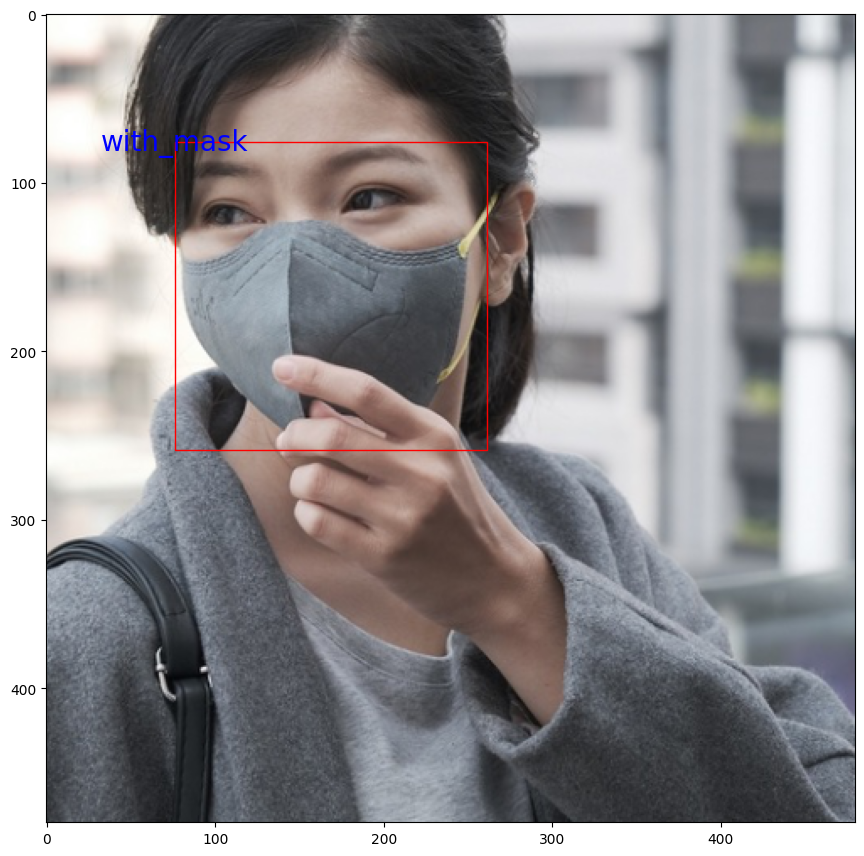

In [16]:
nms_prediction = apply_nms(preds[4], iou_thresh=0.2)
print("Prediction")
plot_image(imgs[4], nms_prediction)
print("Target")
plot_image(imgs[4].to('cpu'), annotations[4],False)

Prediction


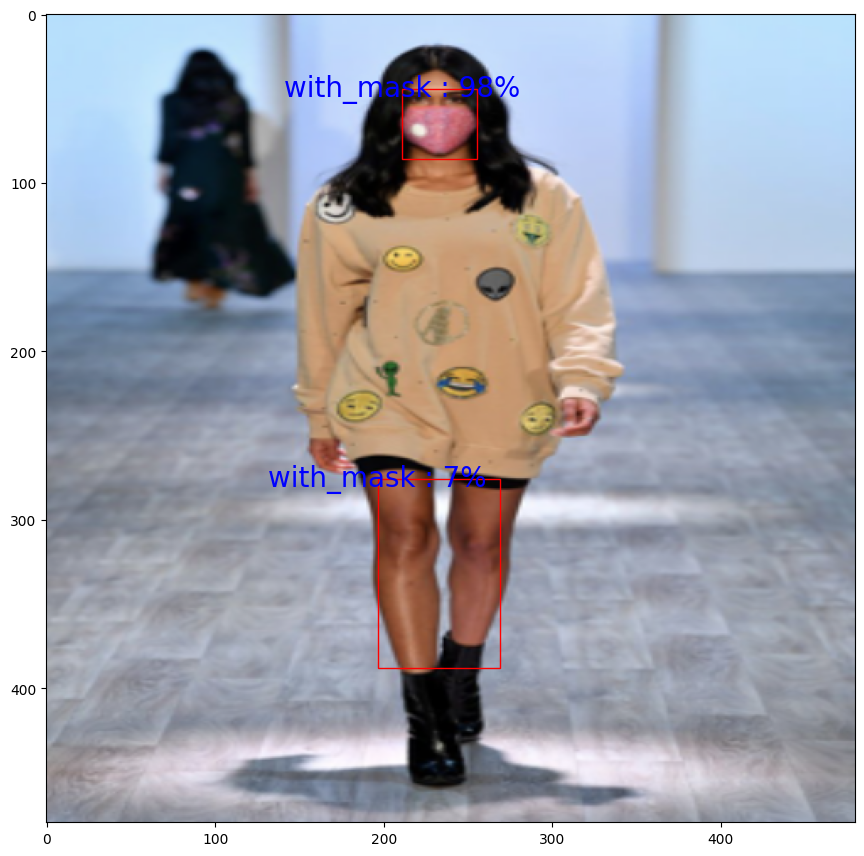

Target


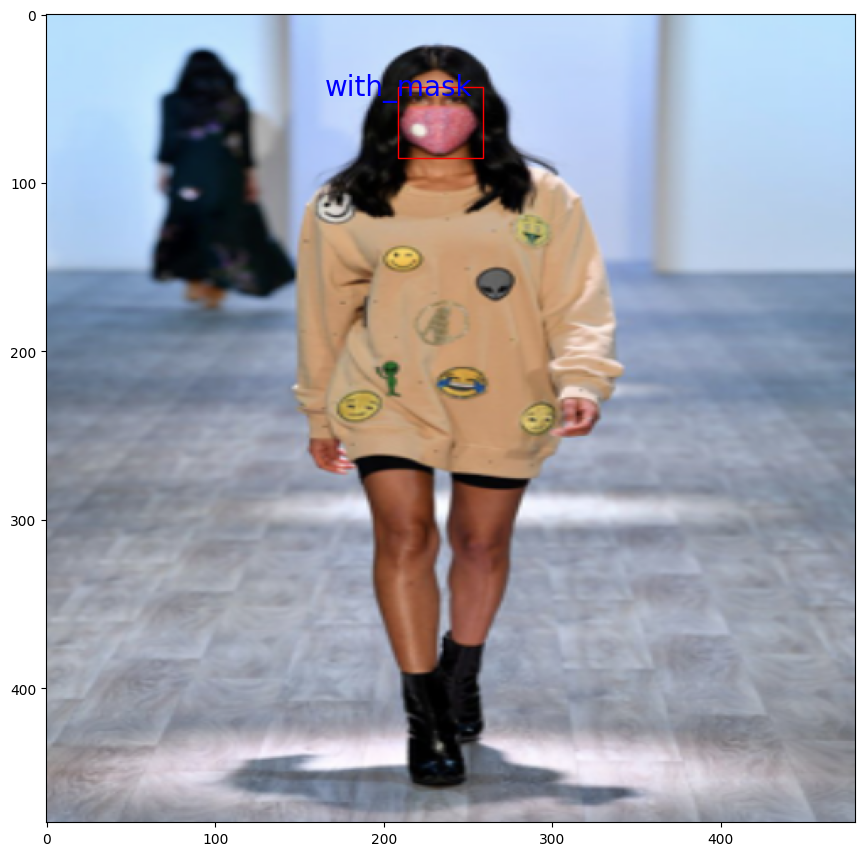

In [17]:
nms_prediction = apply_nms(preds[7], iou_thresh=0.2)
print("Prediction")
plot_image(imgs[7], nms_prediction)
print("Target")
plot_image(imgs[7].to('cpu'), annotations[7],False)

Prediction


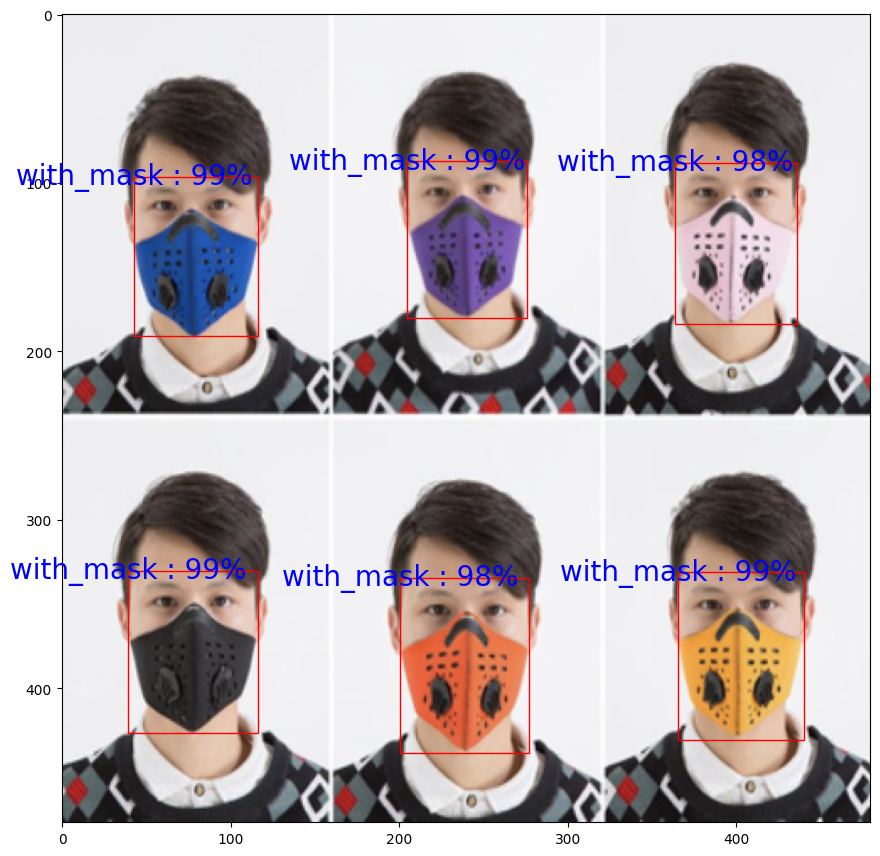

Target


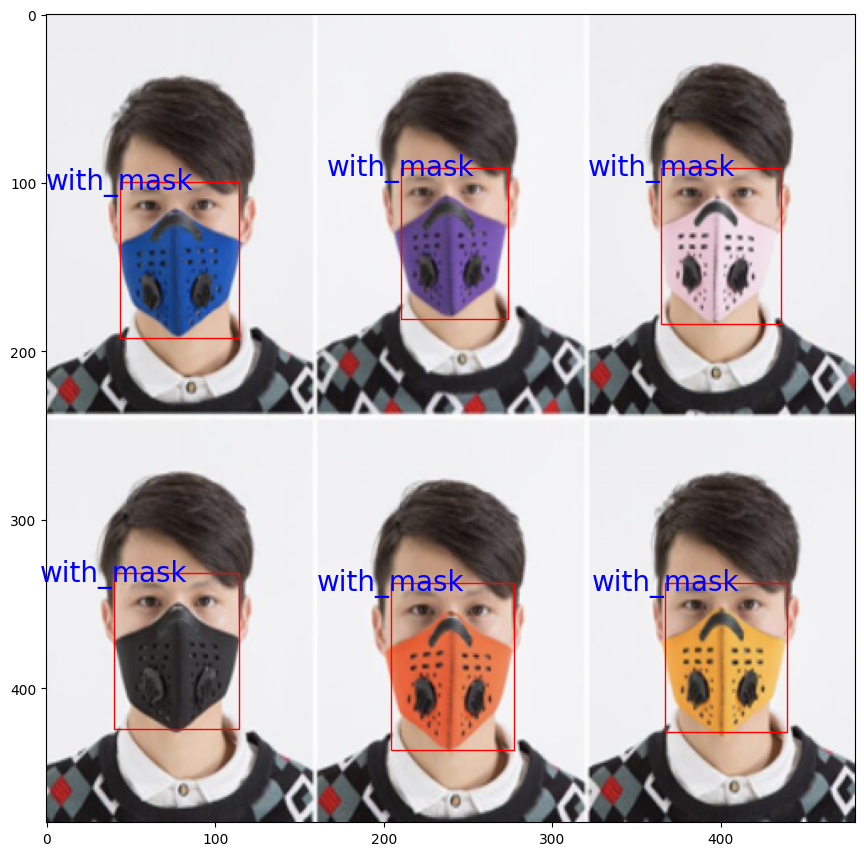

In [18]:
nms_prediction = apply_nms(preds[0], iou_thresh=0.2)
print("Prediction")
plot_image(imgs[0], nms_prediction)
print("Target")
plot_image(imgs[0].to('cpu'), annotations[0],False)

Prediction


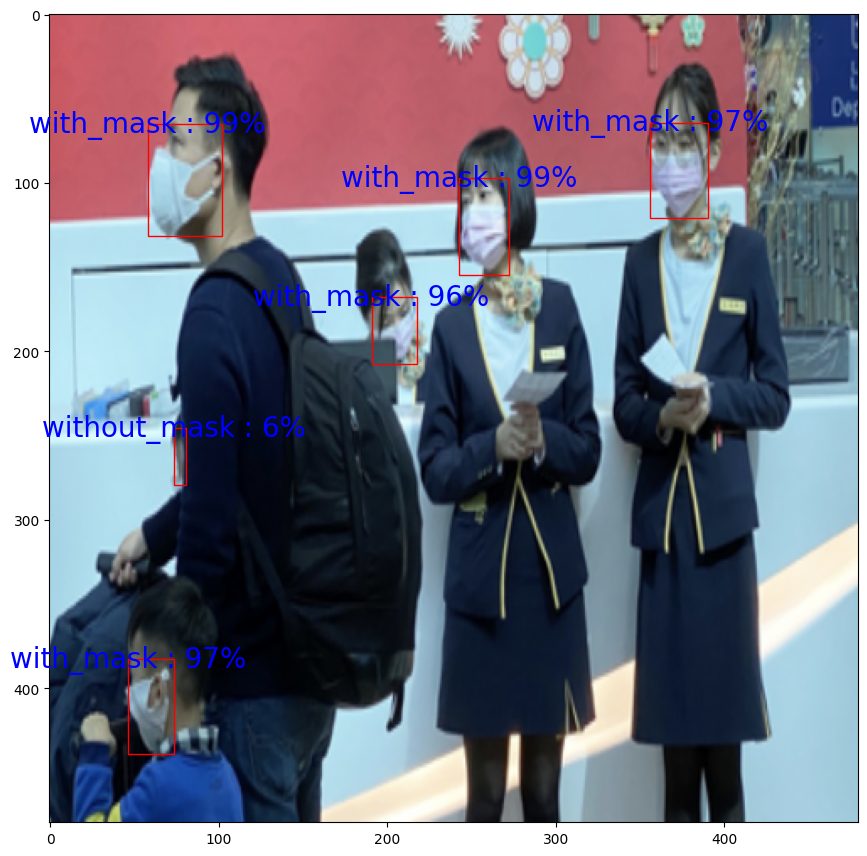

Target


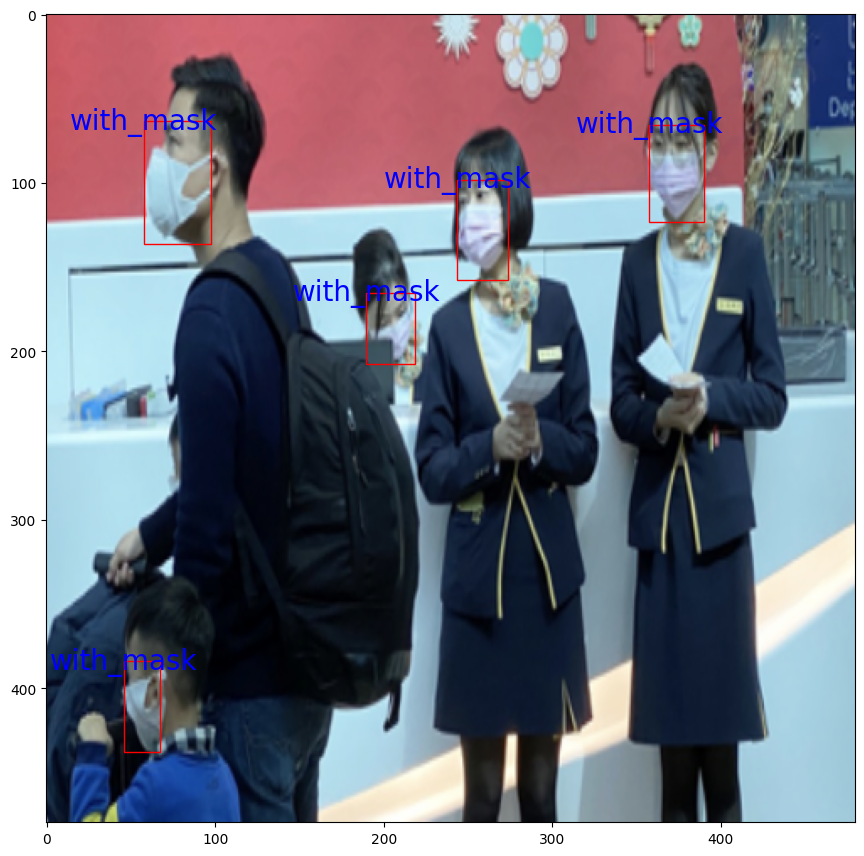

In [19]:
nms_prediction = apply_nms(preds[2], iou_thresh=0.2)
print("Prediction")
plot_image(imgs[2], nms_prediction)
print("Target")
plot_image(imgs[2].to('cpu'), annotations[2],False)

In [20]:
# Функция расчёта AP для одного IoU
def compute_ap(recall, precision):
    """
    11-point interpolation (COCO-style approximation)
    """
    recall = np.concatenate(([0.0], recall, [1.0]))
    precision = np.concatenate(([0.0], precision, [0.0]))

    for i in range(len(precision) - 1, 0, -1):
        precision[i - 1] = np.maximum(precision[i - 1], precision[i])

    indices = np.where(recall[1:] != recall[:-1])[0]
    ap = np.sum((recall[indices + 1] - recall[indices]) * precision[indices + 1])
    return ap

In [21]:
# функция оценки mAP
def evaluate_map_per_class(model, data_loader, device, num_classes):
    model.eval()

    iou_thresholds = np.arange(0.5, 1.0, 0.05)
    aps = {c: [] for c in range(1, num_classes)}  # без background

    with torch.no_grad():
        for iou_thresh in iou_thresholds:

            class_aps = []

            for cls in range(1, num_classes):

                all_scores = []
                all_matches = []
                total_gt = 0

                for images, targets in tqdm(data_loader, leave=False):
                    images = [img.to(device) for img in images]
                    outputs = model(images)

                    for i in range(len(images)):
                        gt_boxes = targets[i]["boxes"][targets[i]["labels"] == cls]
                        pred_boxes = outputs[i]["boxes"][outputs[i]["labels"] == cls]
                        scores = outputs[i]["scores"][outputs[i]["labels"] == cls]

                        total_gt += len(gt_boxes)

                        if len(pred_boxes) == 0:
                            continue

                        if len(gt_boxes) == 0:
                            all_scores.extend(scores.cpu().numpy())
                            all_matches.extend([0] * len(scores))
                            continue

                        ious = box_iou(pred_boxes, gt_boxes)
                        max_iou, indices = ious.max(dim=1)

                        for j in range(len(pred_boxes)):
                            all_scores.append(scores[j].item())
                            if max_iou[j] >= iou_thresh:
                                all_matches.append(1)
                            else:
                                all_matches.append(0)

                if total_gt == 0:
                    aps[cls].append(0)
                    continue

                all_scores = np.array(all_scores)
                all_matches = np.array(all_matches)

                if len(all_scores) == 0:
                    aps[cls].append(0)
                    continue

                sorted_indices = np.argsort(-all_scores)
                all_matches = all_matches[sorted_indices]

                tp = np.cumsum(all_matches)
                fp = np.cumsum(1 - all_matches)

                recall = tp / total_gt
                precision = tp / (tp + fp + 1e-6)

                ap = compute_ap(recall, precision)
                aps[cls].append(ap)

    results = {}

    for cls in range(1, num_classes):
        results[cls] = {
            "AP50": aps[cls][0],                  # IoU=0.5
            "AP50-95": np.mean(aps[cls])          # среднее по IoU
        }

    mAP50 = np.mean([results[c]["AP50"] for c in results])
    mAP5095 = np.mean([results[c]["AP50-95"] for c in results])

    return results, mAP50, mAP5095

In [22]:
#from torchvision.ops import box_iou
# запуск подсчета mAP для train и valid
device = torch.device("cpu")
model.to(device)

print("===== TRAIN =====")
train_results, train_map50, train_map5095 = evaluate_map_per_class(
    model, data_loader, device, num_classes=4
)

print("\n===== VALID =====")
val_results, val_map50, val_map5095 = evaluate_map_per_class(
    model, data_loader_test, device, num_classes=4
)

===== TRAIN =====



===== VALID =====


In [23]:
# вывод по классам
class_names = {
    1: "without_mask",
    2: "with_mask",
    3: "mask_weared_incorrect"
}

print("\n==== TRAIN PER CLASS ====")
for cls in train_results:
    print(f"{class_names[cls]:25} "
          f"AP50: {train_results[cls]['AP50']:.4f} | "
          f"AP50-95: {train_results[cls]['AP50-95']:.4f}")

print(f"\nTrain mAP50: {train_map50:.4f}")
print(f"Train mAP50-95: {train_map5095:.4f}")


print("\n==== VALID PER CLASS ====")
for cls in val_results:
    print(f"{class_names[cls]:25} "
          f"AP50: {val_results[cls]['AP50']:.4f} | "
          f"AP50-95: {val_results[cls]['AP50-95']:.4f}")

print(f"\nValid mAP50: {val_map50:.4f}")
print(f"Valid mAP50-95: {val_map5095:.4f}")


==== TRAIN PER CLASS ====
without_mask              AP50: 0.9549 | AP50-95: 0.5746
with_mask                 AP50: 0.9876 | AP50-95: 0.6838
mask_weared_incorrect     AP50: 0.5805 | AP50-95: 0.3153

Train mAP50: 0.8410
Train mAP50-95: 0.5246

==== VALID PER CLASS ====
without_mask              AP50: 0.7662 | AP50-95: 0.4027
with_mask                 AP50: 0.9138 | AP50-95: 0.5646
mask_weared_incorrect     AP50: 0.3837 | AP50-95: 0.1500

Valid mAP50: 0.6879
Valid mAP50-95: 0.3724


Модель Faster R-CNN показала неплохие результаты на коротком обучении (5 эпох): метрики на валидационной выборке mAP50: 0.6879, Valid mAP50-95: 0.3724.
По классам плохой результат для mask_weared_incorrect, что связано с малым числом образцов. Корректность использования модели подтверждается также и монотонно убывающей функцией потерь с каждой эпохой.
Время на обучение составило 11.73 часа. Очевидно, такого рода задачи надо решать с использованием 'cuda', что не всегда доступно. 

# Модель YOLOv8

In [25]:
# формирование структуры папок для модели YOLO
# Исходные папки
IMAGES_DIR = Path("images")
ANNOTATIONS_DIR = Path("annotations")

# Целевая папка
DATASET_DIR = Path("dataset_yolo")

# Создание структуры папок
for split in ["train", "valid"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Структура директорий создана.")

Структура директорий создана.


In [26]:
CLASSES = ["without_mask", "with_mask", "mask_weared_incorrect"]

class_to_id = {name: idx for idx, name in enumerate(CLASSES)}

print("Классы:", class_to_id)

Классы: {'without_mask': 0, 'with_mask': 1, 'mask_weared_incorrect': 2}


In [29]:
# преобразование аннотации из формата xml в формат YOLO
def convert_xml_to_yolo(xml_path, output_txt_path):
    tree = et.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name not in class_to_id:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        if xmax > width:
            xmax = width
        ymax = int(bbox.find("ymax").text)

        # YOLO формат (нормализация)
        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        bbox_width = (xmax - xmin) / width
        bbox_height = (ymax - ymin) / height

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}"
        )

    # В Windows лучше явно указать кодировку
    with open(output_txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(yolo_lines))

In [30]:

# Получаем список XML
xml_files = list(ANNOTATIONS_DIR.glob("*.xml"))

# Перемешиваем (важно!)
random.seed(42)
random.shuffle(xml_files)

# формирование датасета с разделением на train  и valid  80/20
split_index = int(len(xml_files) * 0.8)
train_files = xml_files[:split_index]
valid_files = xml_files[split_index:]

def process_split(file_list, split_name):
    for xml_path in file_list:
        file_stem = xml_path.stem
        image_path = IMAGES_DIR / f"{file_stem}.png"

        if not image_path.exists():
            print(f"Изображение не найдено: {image_path}")
            continue

        # Копирование изображения
        shutil.copy2(
            image_path,
            DATASET_DIR / "images" / split_name / image_path.name
        )

        # Конвертация аннотации
        output_txt = DATASET_DIR / "labels" / split_name / f"{file_stem}.txt"
        convert_xml_to_yolo(xml_path, output_txt)

# Запуск
process_split(train_files, "train")
process_split(valid_files, "valid")

print("Датасет сформирован.")
print(f"Train: {len(train_files)}")
print(f"Valid: {len(valid_files)}")

Датасет сформирован.
Train: 682
Valid: 171


In [31]:
# формирование файла для IOLOv8
data_yaml = f"""path: {DATASET_DIR.resolve()}
train: images/train
val: images/valid

names:
"""

for i, name in enumerate(CLASSES):
    data_yaml += f"  {i}: {name}\n"

with open(DATASET_DIR / "data.yaml", "w", encoding="utf-8") as f:
    f.write(data_yaml)

print("data.yaml создан.")

data.yaml создан.


In [37]:
# отрисовка изображения с выделенными объектами
def show_image_with_bboxes(filename, split="train"):
    """
    filename — имя файла БЕЗ расширения (например: 'maksssksksss99')
    split — 'train' или 'valid'
    """

    image_path = DATASET_DIR / "images" / split / f"{filename}.png"
    label_path = DATASET_DIR / "labels" / split / f"{filename}.txt"

    if not image_path.exists():
        print(f"Изображение не найдено: {image_path}")
        return
    
    if not label_path.exists():
        print(f"Файл аннотаций не найден: {label_path}")
        return

    # Загружаем изображение
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    # Читаем аннотации YOLO
    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        x_center, y_center, bbox_width, bbox_height = map(float, parts[1:])

        # Перевод обратно в пиксели
        x_center *= w
        y_center *= h
        bbox_width *= w
        bbox_height *= h

        xmin = int(x_center - bbox_width / 2)
        ymin = int(y_center - bbox_height / 2)
        xmax = int(x_center + bbox_width / 2)
        ymax = int(y_center + bbox_height / 2)

        # Рисуем bbox
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

        # Подпись класса
        label = CLASSES[class_id]
        cv2.putText(
            image,
            label,
            (xmin, ymin - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            1
        )

    # Отображаем
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{filename} ({split})")
    plt.show()

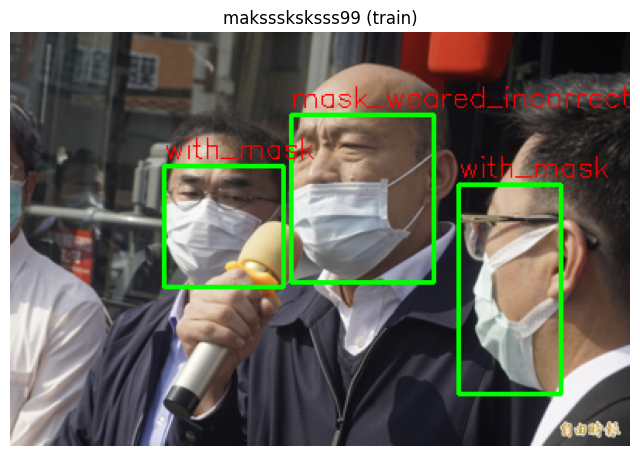

In [38]:
show_image_with_bboxes("maksssksksss99", split="train")

In [39]:
model = YOLO("yolov8m.pt")  # предобученные веса
DATA_YAML = "dataset_yolo/data.yaml"

In [40]:
# функция обучения с сохранением реузльтатов
def get_loss_and_time_history(model):
    """
    Возвращает списки total loss и времени по эпохам из results.csv
    
    Параметры:
    - model: YOLOv8 объект после вызова model.train()
    
    Возвращает:
    - loss_history: список float (total loss по эпохам)
    - epoch_times: список float (время каждой эпохи, сек)
    - save_dir: Path к директории, где лежит results.csv
    """
    # Проверяем, есть ли save_dir
    save_dir = getattr(model.trainer, 'save_dir', None)
    if save_dir is None:
        raise ValueError("model.trainer.save_dir не найден. Обучение не запускалось.")
    
    save_dir = Path(save_dir)
    results_csv = save_dir / "results.csv"
    
    # Если файла нет, ищем любой CSV в папке
    if not results_csv.exists():
        csv_files = list(save_dir.glob("*.csv"))
        if csv_files:
            results_csv = csv_files[-1]  # берём последний
            print(f"Используем CSV: {results_csv}")
        else:
            raise FileNotFoundError(f"results.csv не найден в {save_dir}")
    
    # Читаем CSV
    df = pd.read_csv(results_csv)
    
    # total loss = box_loss + cls_loss + dfl_loss
    loss_history = (df["train/box_loss"] + df["train/cls_loss"] + df["train/dfl_loss"]).tolist()
    
    # Время каждой эпохи
    if "time" in df.columns:
        epoch_times = df["time"].tolist()
    else:
        epoch_times = [None]*len(loss_history)  # если колонки нет
    
    return loss_history, epoch_times, save_dir

In [41]:
# обучение модели
start_time = time.time()

results = model.train(
    data=DATA_YAML,   # путь к YAML с dataset
    epochs=5,         # обучаем сразу 5 эпох
    imgsz=640,        # размер входных изображений
    batch=8,          # batch для CPU
    device='cpu',     # CPU
    verbose=True      # показывать прогресс
)

total_time = time.time() - start_time
print(f"\nОбщее время обучения: {total_time:.2f} сек")

New https://pypi.org/project/ultralytics/8.4.18 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.252  Python-3.9.12 torch-2.8.0+cpu CPU (Intel Core i3-10100 3.60GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimi

In [42]:
# Вывод по эпохам функции потерь и затрат времени на обучение
loss_history, epoch_times, save_dir = get_loss_and_time_history(model)

print(f"CSV файл с результатами находится в: {save_dir}")
for i, (l, t) in enumerate(zip(loss_history, epoch_times)):
    print(f"Epoch {i+1}: Loss={l:.4f}, Time={t:.2f} сек")

CSV файл с результатами находится в: D:\Projects\python\skillfactory_2year\Track CV-enginear Base Tasks Computer  Project2 Detective medical masok\runs\detect\train4
Epoch 1: Loss=4.3454, Time=3649.84 сек
Epoch 2: Loss=3.3730, Time=7418.03 сек
Epoch 3: Loss=3.1603, Time=11008.90 сек
Epoch 4: Loss=2.9887, Time=14652.30 сек
Epoch 5: Loss=2.8402, Time=18181.10 сек


In [43]:
# Подсчет метрик
# Valid
metrics_valid = model.val(data=DATA_YAML)
print("\nVALID METRICS:")
print("mAP50:", metrics_valid.box.map50)
print("mAP50-95:", metrics_valid.box.map)

# Train
metrics_train = model.val(data=DATA_YAML, split="train")
print("\nTRAIN METRICS:")
print("mAP50:", metrics_train.box.map50)
print("mAP50-95:", metrics_train.box.map)

Ultralytics 8.3.252  Python-3.9.12 torch-2.8.0+cpu CPU (Intel Core i3-10100 3.60GHz)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 20.77.0 MB/s, size: 532.0 KB)
val: Scanning D:\Projects\python\skillfactory_2year\Track CV-enginear Base Tasks Computer  Project2 Detective medical masok\dataset_yolo\labels\valid.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 5.9s/it 1:056.5ss
                   all        171        734      0.804      0.758      0.809      0.545
          without_mask         53        105      0.887      0.762      0.854      0.534
             with_mask        156        607      0.879      0.922      0.953      0.662
 mask_weared_incorrect         19         22      0.646      0.591      0.619       0.44
Speed: 2.0ms preprocess, 343.9ms infer

На 171 изображении 734 объекта. Из всех найденных объектов 81% - правильные.Модель находит 81% (Recall) реальных объектов. Она пропускает около 19% объектов. Метрики mAP50 = 0.81 и mAP50-95 = 0.545 являются хорошим результатом для короткого обучения. Наилучший результат по классу "with mask" по причине широкого представительства - 607 объектов, наихудший - по классу "mask_weared_incorrect" по причине малого числа объектоа - 22. Возможные варианты улучшения - увеличить вес класса, добавить аугментацию для редкого класса. Увеличение числа эпох с использованием 'cpu' не представляется возможным, покольку версия yolov8m является тяжелой для 'cpu'.

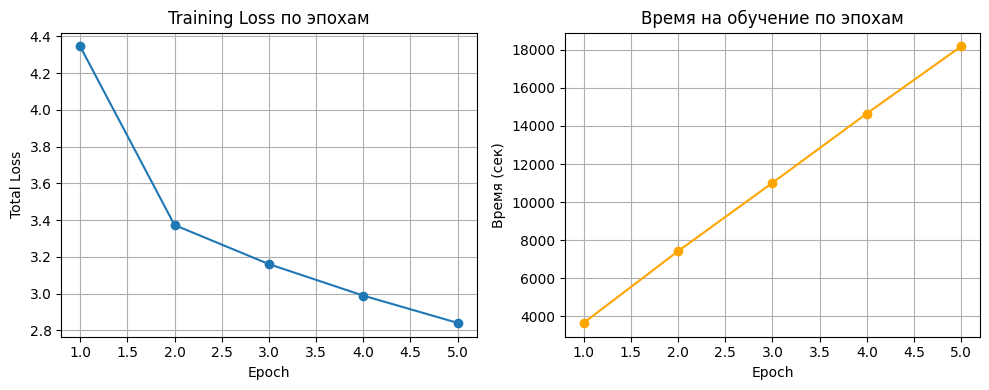

In [44]:
# Графики функции потерь и времени на обучение
plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(range(1,len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss по эпохам")
plt.grid(True)

# Время
plt.subplot(1,2,2)
plt.plot(range(1,len(epoch_times)+1), epoch_times, marker='o', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Время (сек)")
plt.title("Время на обучение по эпохам")
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
# функция визуализации предсказания модели по заданному файлу
def show_prediction(image_name, split="valid", conf=0.25):
    """
    Отображает результат предсказания модели на одном изображении.

    image_name : имя файла .png
    split      : 'train' или 'valid'
    conf       : порог confidence
    """

    # путь к изображению
    img_path = DATASET_DIR / "images" / split / image_name

    if not img_path.exists():
        raise FileNotFoundError(f"{img_path} не найден")

    # предсказание
    results = model.predict(str(img_path), conf=conf, verbose=False)

    # исходное изображение
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # отрисовка bbox
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        score = float(box.conf[0])

        label = f"{model.names[cls_id]} {score:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
        cv2.putText(img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255, 0, 0), 1)

    # отображение
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(f"Prediction: {image_name}")
    plt.axis("off")
    plt.show()

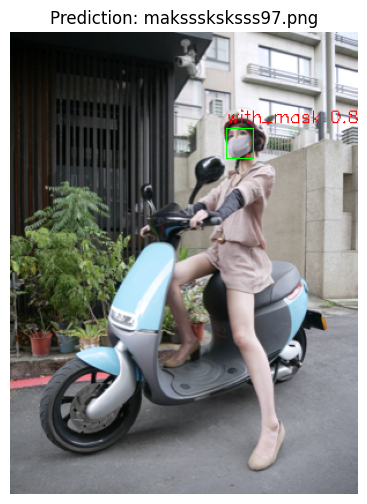

In [46]:
show_prediction("maksssksksss97.png", split="train")

Сравнение результатов Faster R-CNN и YOLOv8 на валидационной выборке.

На коротком обучении, обусловленном применением 'cpu', метрики YOLOv8 (mAP50: 0.808, mAP50-95: 0.545) существенно выше, чем Faster R-CNN 
(mAP50: 0.688, mAP50-95: 0.372). В пользу этой сети говорит и время, потраченное на обучение - 5.08 часа, против 11.73 часа у сети Faster R-CNN. Об этом было известно априори.
           
Окончательные выводы в части лучших метрик в пользу YOLOv8 делать преждевременно из-за ограниченных объемов испытаний и используемых вариантов трансформаций исходных примеров.
